# Reconstructing the past: estimating solar radio flux F10.7 from sunspot records
# Ilya Niafiodau, Vlad Zagorodnyuk, Zhanar Sirgebayeva, Skoltech, 2026

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

In [19]:
# Read data from txt files
flux_year, flux_month, flux = np.loadtxt("Radio_flux_monthly_mean.txt", unpack=True)
sunspot_year, sunspot_month, sunspot = np.loadtxt("Sunspot_number_monthly_mean.txt", unpack=True)

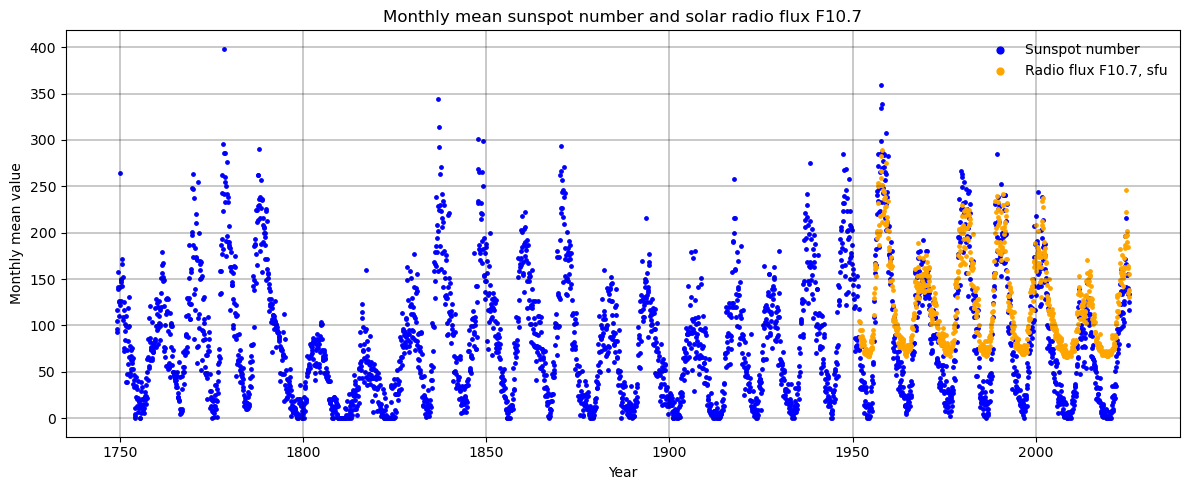

In [ ]:
# plot the data

flux_time = flux_year + (flux_month - 1) / 12
sunspot_time = sunspot_year + (sunspot_month - 1) / 12

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(sunspot_time, sunspot, s=6, color="blue", label="Sunspot number")
ax.scatter(flux_time, flux, s=6, color="orange", label="Radio flux F10.7, sfu")

ax.set_title("Monthly mean sunspot number and solar radio flux F10.7")
ax.set_xlabel("Year")
ax.set_ylabel("Monthly mean value")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, markerscale=2)

fig.tight_layout()
plt.show()

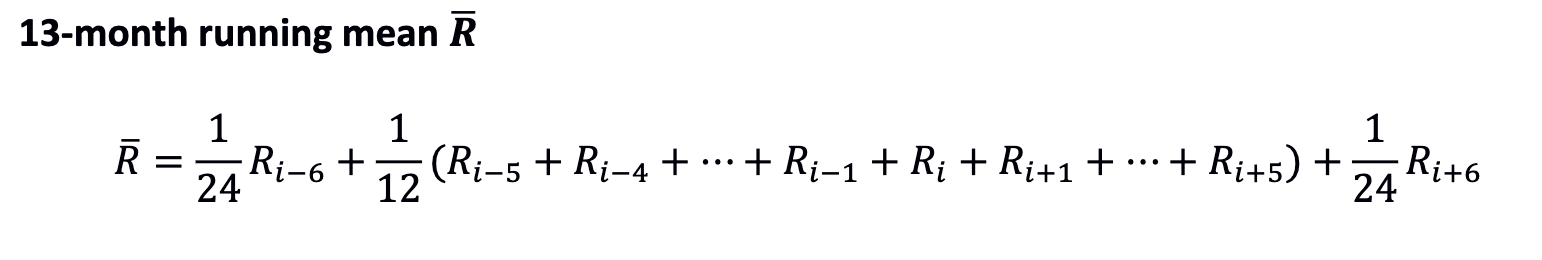

In [20]:
# adjust simple smoothing

def smooth(data, time):
    n = len(time)
    smoothed = data
    for i in range(6, n-6):
        sum = data[i-6] / 24 
        for j in range(i-5, i+6):
            sum += 1 / 12 * data[j]
        sum += data[i+6] / 24
        smoothed[j] = sum
    return smoothed

sunspot_smoothed = smooth(sunspot, sunspot_time)
flux_smoothed = smooth(flux, flux_time)

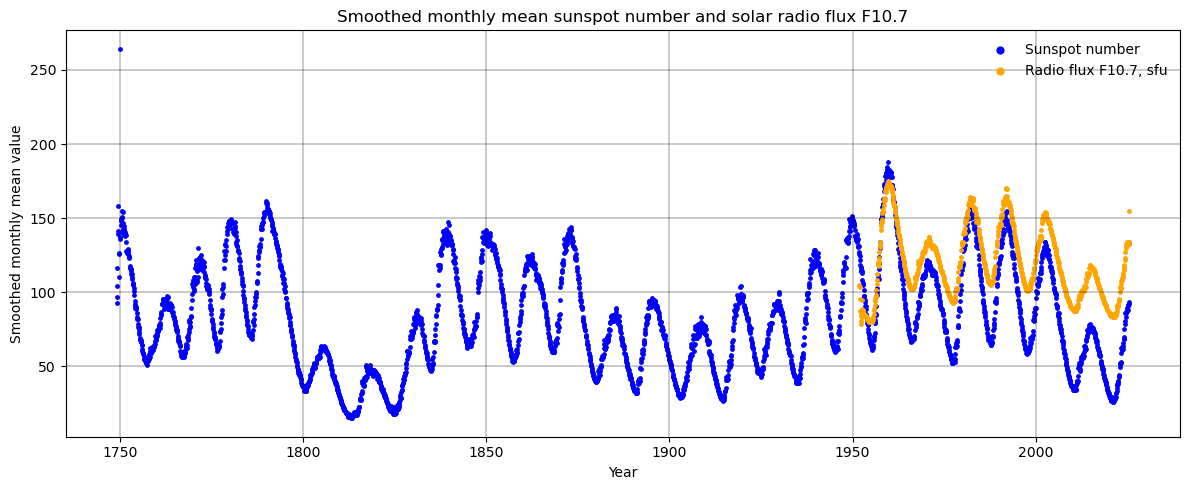

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(sunspot_time, sunspot_smoothed, s=6, color="blue", label="Sunspot number")
ax.scatter(flux_time, flux_smoothed, s=6, color="orange", label="Radio flux F10.7, sfu")

ax.set_title("Smoothed monthly mean sunspot number and solar radio flux F10.7")
ax.set_xlabel("Year")
ax.set_ylabel("Smoothed monthly mean value")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, markerscale=2)

fig.tight_layout()
plt.show()

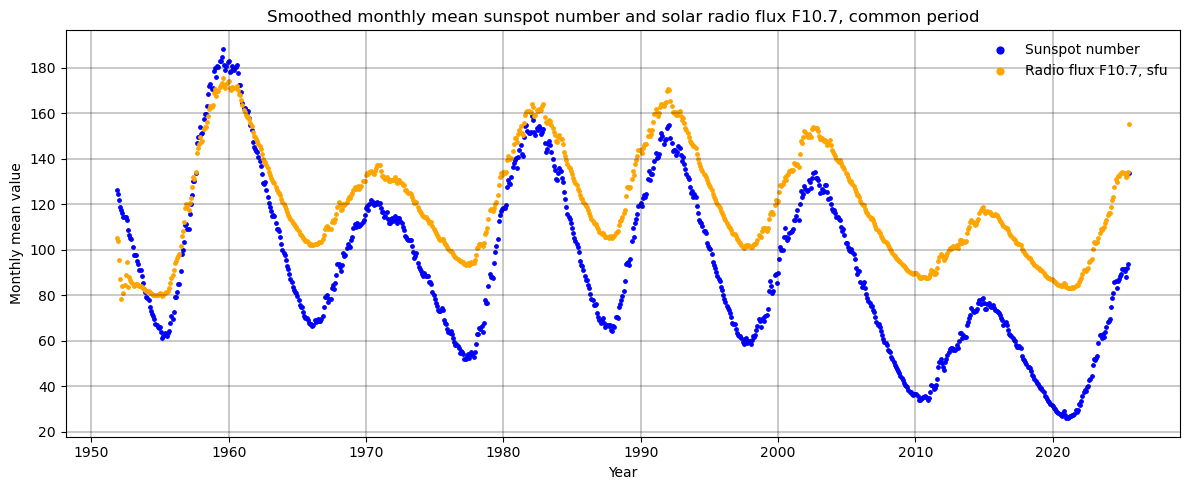

In [22]:
# looking for a comon start time and end time periods
common_start = max(sunspot_time[0], flux_time[0])
common_end = min(sunspot_time[-1], flux_time[-1])

sunspot_mask = (sunspot_time >= common_start) & (sunspot_time <= common_end)
flux_mask = (flux_time >= common_start) & (flux_time <= common_end)

# extract data from a common timeline
common_time = sunspot_time[sunspot_mask]
sunspot_common = sunspot[sunspot_mask]
flux_common = flux[flux_mask]
sunspot_smoothed_common = sunspot_smoothed[sunspot_mask]
flux_smoothed_common = flux_smoothed[flux_mask]

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(common_time, sunspot_common, s=6, color="blue", label="Sunspot number")
ax.scatter(common_time, flux_common, s=6, color="orange", label="Radio flux F10.7, sfu")

ax.set_title("Smoothed monthly mean sunspot number and solar radio flux F10.7, common period")
ax.set_xlabel("Year")
ax.set_ylabel("Monthly mean value")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, markerscale=2)

fig.tight_layout()
plt.show()

# Conclusions:
both dependencies have:
- same periods
- same max and mins points (extremums)

looks like they have a linear dependency

# Multi-dimensional linear regression model:
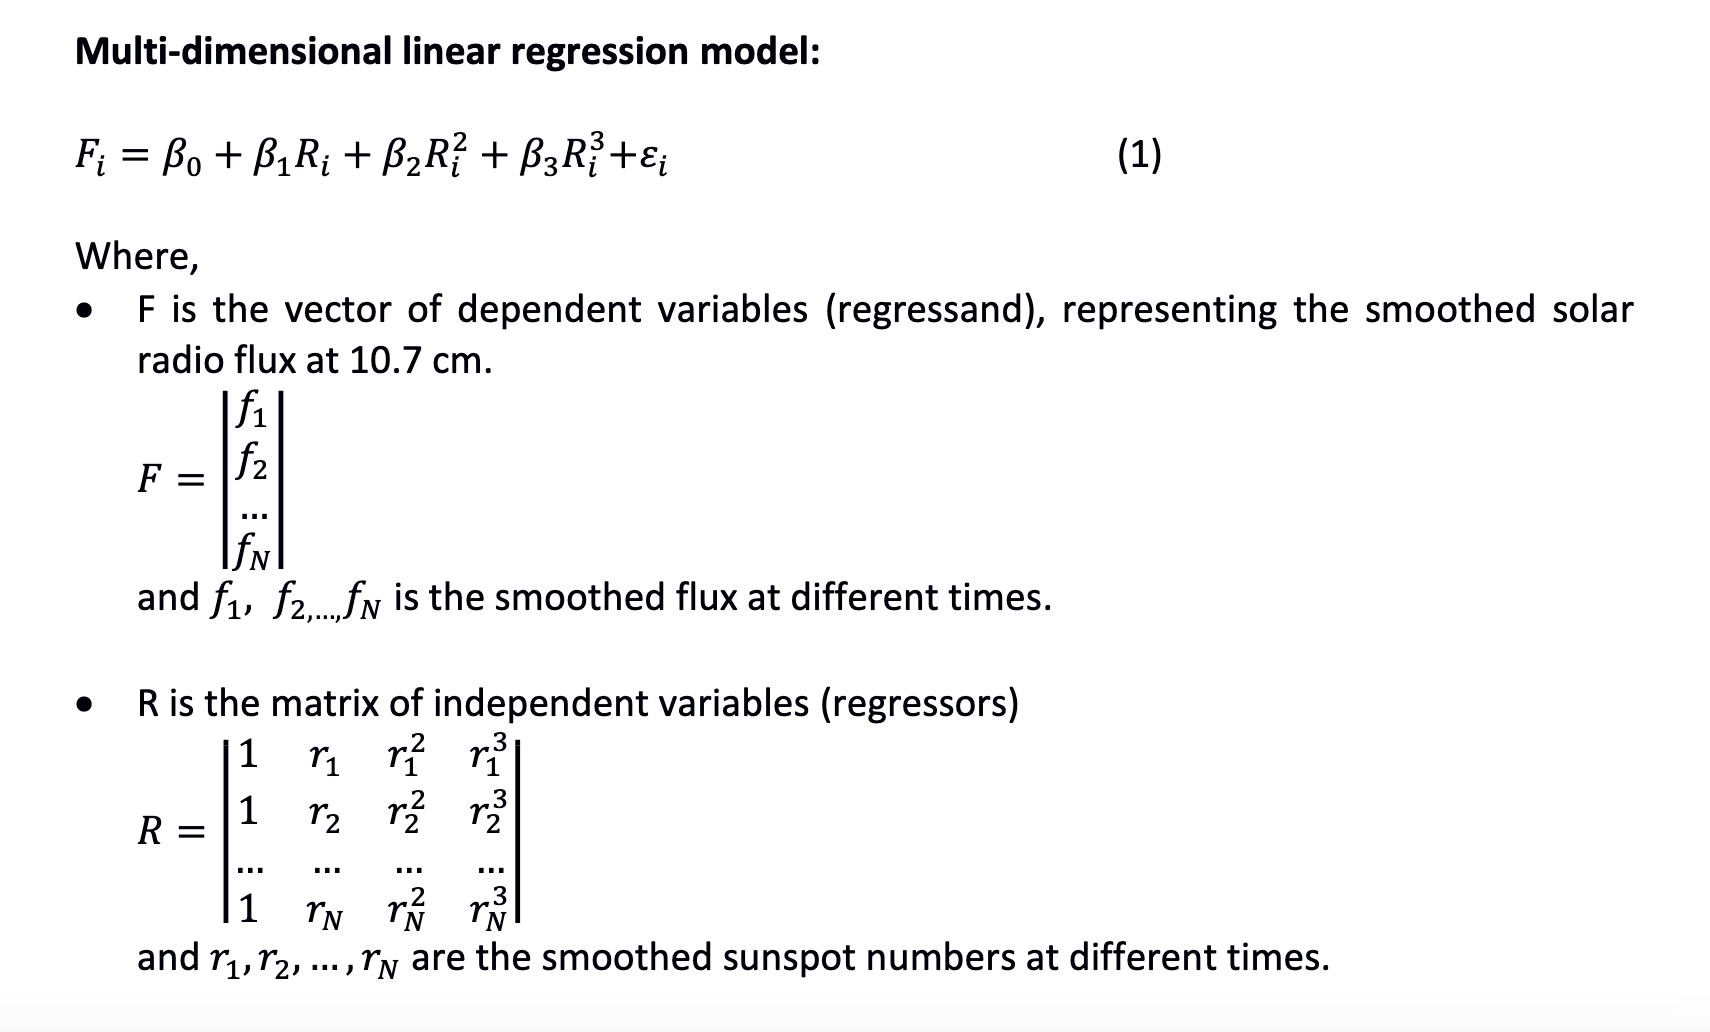
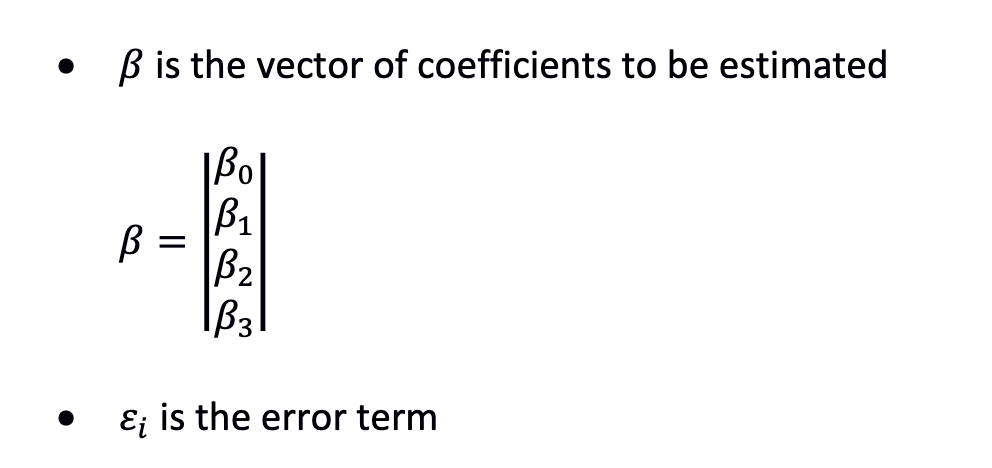

In [ ]:
r = sunspot_smoothed_common
f = flux_smoothed_common

# R: (1, r_i, r_i^2, r_i^3) - one row per month
# F: column of f_i
R = np.column_stack((np.ones(r.size), r, r**2, r**3))
F = f.reshape(-1, 1)

# Least squares estimate: beta = (R^T R)^-1 R^T F
beta = np.linalg.inv(R.T @ R) @ R.T @ F

print("R:", R.shape, " F:", F.shape, " beta:", beta.shape)
print(beta)

R: (886, 4)  F: (886, 1)  beta: (4, 1)
[[ 8.35861022e+01]
 [-2.65666514e-02]
 [ 5.90278073e-03]
 [-1.67057295e-05]]


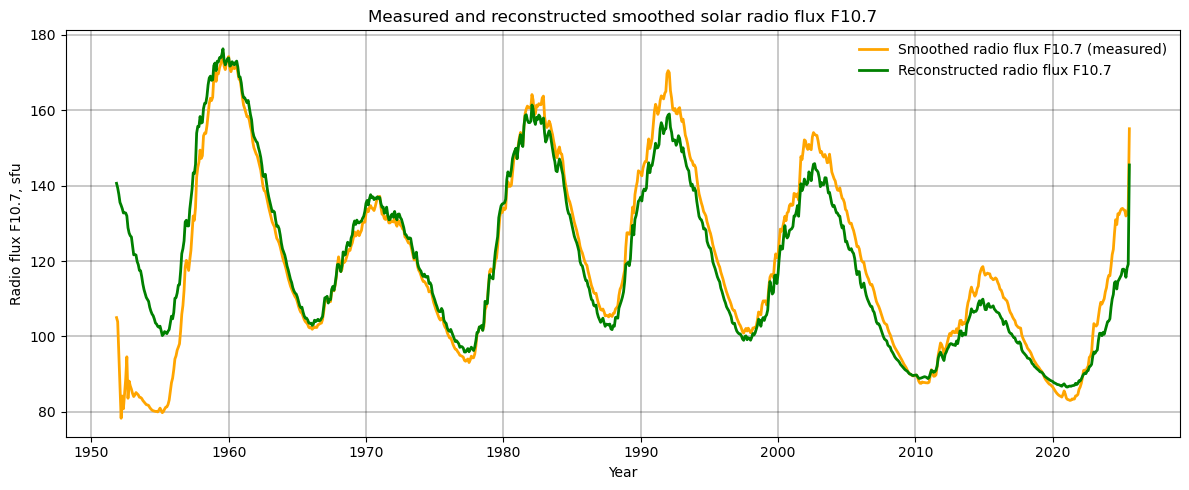

In [25]:
# reconstruct smoothed flux
# F = beta0 + beta1*r + beta2*r^2 + beta3*r^3
F_reconstructed = R @ beta
flux_reconstructed = F_reconstructed.ravel()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(common_time, flux_smoothed_common, linewidth=2, color="orange", label="Smoothed radio flux F10.7 (measured)")
ax.plot(common_time, flux_reconstructed, linewidth=2, color="green", label="Reconstructed radio flux F10.7")

ax.set_title("Measured and reconstructed smoothed solar radio flux F10.7")
ax.set_xlabel("Year")
ax.set_ylabel("Radio flux F10.7, sfu")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()